#**PREDIKSI HARGA RUMAH**

##LIBRARY

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##EDA

In [ ]:
train = pd.read_csv("data/housing_train.csv")

print(train.shape)
train.head()

(16512, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0,NEAR OCEAN
1,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0,NEAR OCEAN
2,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0,NEAR OCEAN
3,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0,NEAR OCEAN
4,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0,INLAND


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB


In [8]:
train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.582290,35.643149,28.608285,2642.004784,538.496851,1426.453004,499.986919,3.880754,207194.693738
std,2.005654,2.136665,12.602499,2174.646744,419.007096,1137.056380,380.967964,1.904294,115622.626448
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.810000,33.930000,18.000000,1454.000000,296.750000,789.000000,280.000000,2.566700,119800.000000
50%,-118.510000,34.260000,29.000000,2129.000000,437.000000,1167.000000,410.000000,3.545800,179850.000000
75%,-118.010000,37.720000,37.000000,3160.000000,647.000000,1726.000000,606.000000,4.773175,265125.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Data Visualization

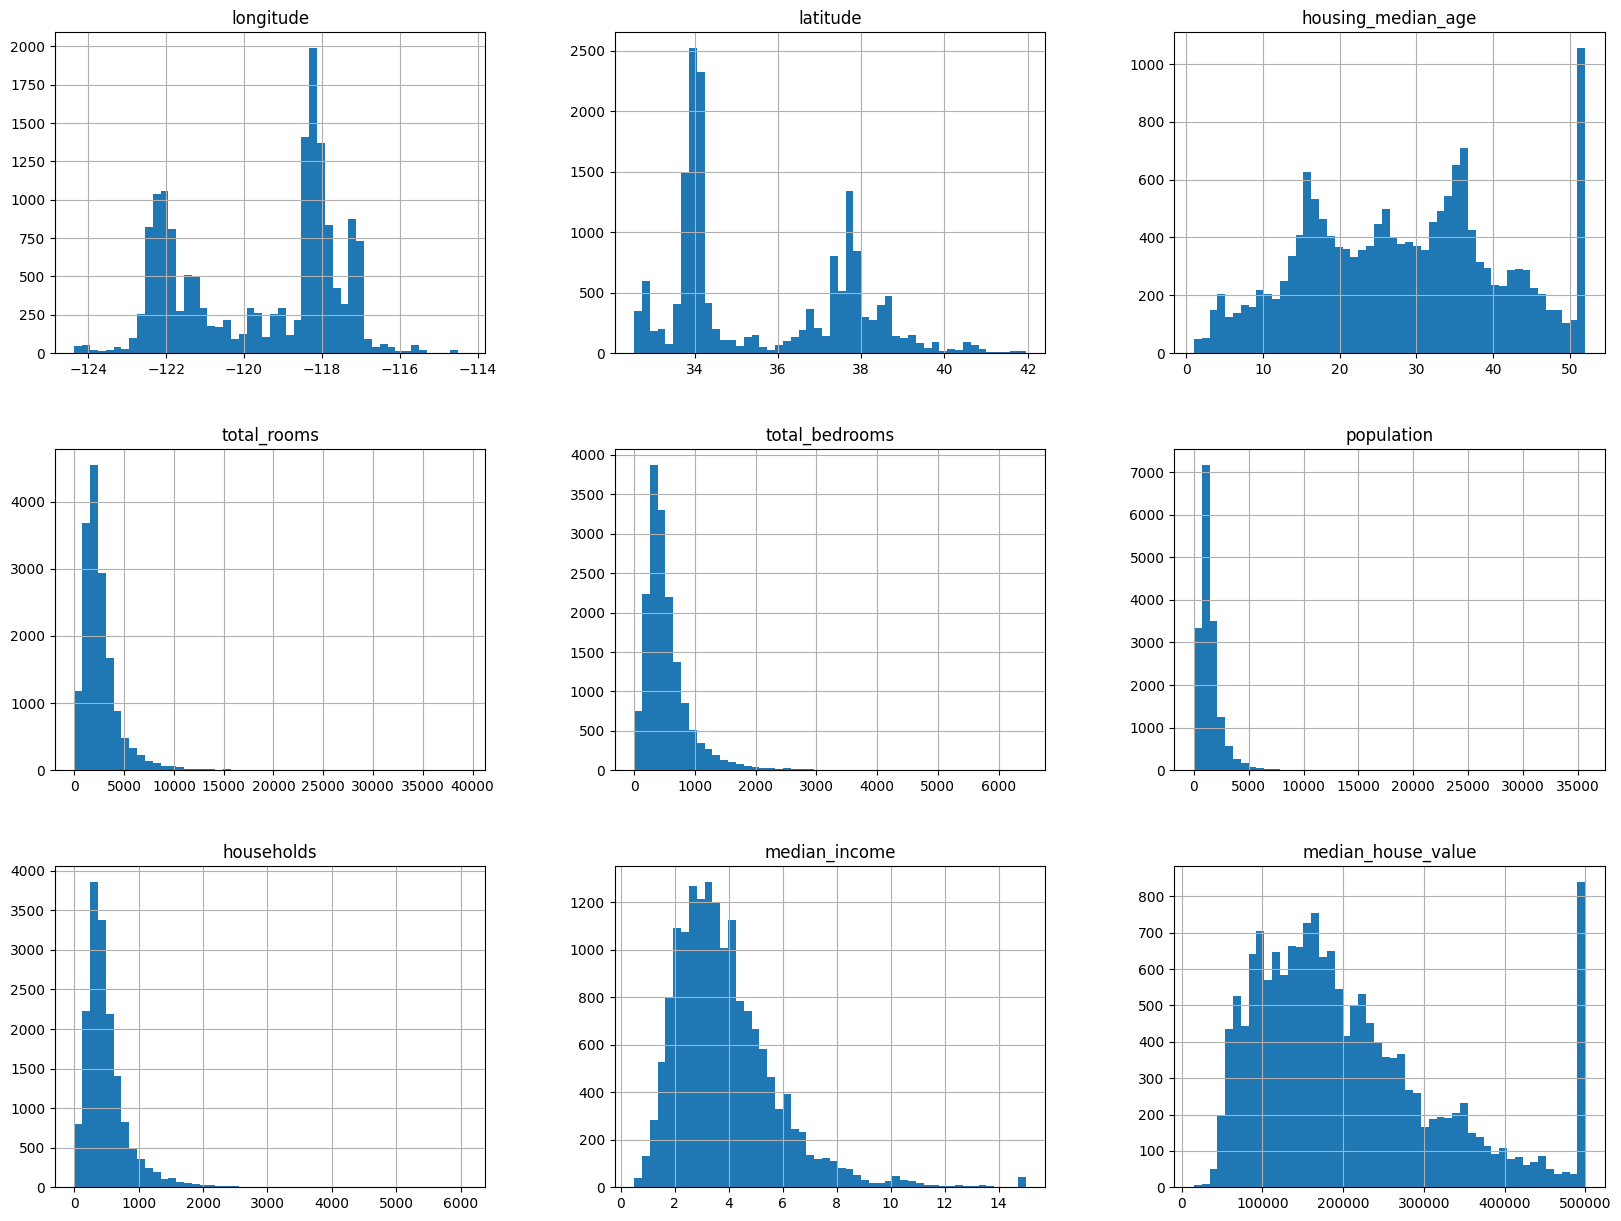

In [9]:
train.hist(bins=50, figsize=(20,15))
plt.show()

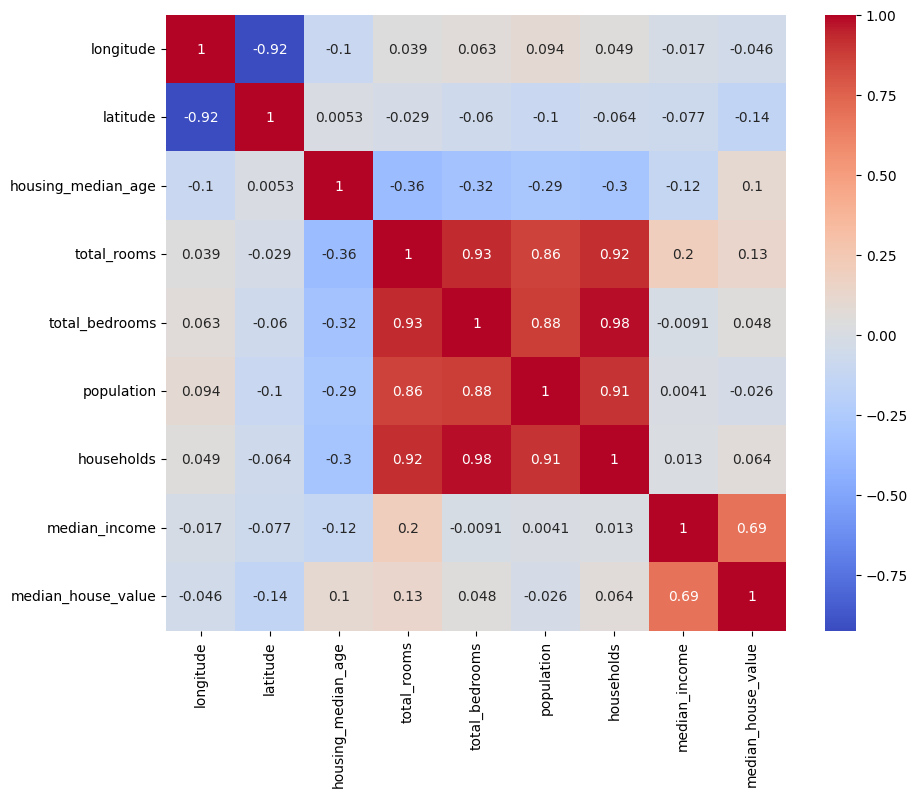

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Data preprocessing

### Subtask:
Menangani nilai yang hilang, mengkodekan fitur kategorikal, dan melakukan penskalaan pada fitur numerik.


**Reasoning**:
Mengidentifikasi dan menangani nilai yang hilang, mengidentifikasi fitur kategorikal, mengkodekan fitur kategorikal, memisahkan variabel target, dan melakukan penskalaan pada fitur numerik.



In [11]:
# Check for missing values
print(train.isnull().sum())

# Handle missing values in 'total_bedrooms' by imputing with the median
train['total_bedrooms'].fillna(train['total_bedrooms'].median(), inplace=True)

# Identify categorical features
categorical_features = train.select_dtypes(include=['object']).columns
print("\nCategorical features:", categorical_features)

# Encode categorical features using one-hot encoding
train_encoded = pd.get_dummies(train, columns=categorical_features)

# Separate target variable and features
X = train_encoded.drop('median_house_value', axis=1)
y = train_encoded['median_house_value']

# Identify numerical features (excluding the target variable and encoded categorical features)
numerical_features = X.select_dtypes(include=np.number).columns

# Scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Store the processed data in a new DataFrame
processed_train = pd.concat([X, y], axis=1)

print("\nProcessed DataFrame shape:", processed_train.shape)
print("\nProcessed DataFrame head:")
display(processed_train.head())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Categorical features: Index(['ocean_proximity'], dtype='object')

Processed DataFrame shape: (16512, 14)

Processed DataFrame head:


/tmp/ipython-input-1686842476.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['total_bedrooms'].fillna(train['total_bedrooms'].median(), inplace=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,median_house_value
0,1.272587,-1.372811,0.348490,0.222569,0.211228,0.768276,0.322906,-0.326196,False,False,False,False,True,103000.0
1,0.709162,-0.876696,1.618118,0.340293,0.593094,-0.098901,0.672027,-0.035843,False,False,False,False,True,382100.0
2,-0.447603,-0.460146,-1.952710,-0.342597,-0.495226,-0.449818,-0.430461,0.144701,False,False,False,False,True,172600.0
3,1.232698,-1.382172,0.586545,-0.561490,-0.409306,-0.007434,-0.380587,-1.017864,False,False,False,False,True,93400.0
4,-0.108551,0.532084,1.142008,-0.119565,-0.256559,-0.485877,-0.314962,-0.171488,False,True,False,False,False,96500.0


## Feature engineering

### Subtask:
Membuat fitur baru yang mungkin berguna untuk model.


**Reasoning**:
Membuat fitur baru dengan menggabungkan fitur yang sudah ada dan menambahkannya ke DataFrame `processed_train`.



In [12]:
processed_train['rooms_per_household'] = processed_train['total_rooms'] / processed_train['households']
processed_train['bedrooms_per_room'] = processed_train['total_bedrooms'] / processed_train['total_rooms']
processed_train['population_per_household'] = processed_train['population'] / processed_train['households']

display(processed_train.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,1.272587,-1.372811,0.348490,0.222569,0.211228,0.768276,0.322906,-0.326196,False,False,False,False,True,103000.0,0.689270,0.949041,2.379257
1,0.709162,-0.876696,1.618118,0.340293,0.593094,-0.098901,0.672027,-0.035843,False,False,False,False,True,382100.0,0.506368,1.742891,-0.147169
2,-0.447603,-0.460146,-1.952710,-0.342597,-0.495226,-0.449818,-0.430461,0.144701,False,False,False,False,True,172600.0,0.795884,1.445506,1.044968
3,1.232698,-1.382172,0.586545,-0.561490,-0.409306,-0.007434,-0.380587,-1.017864,False,False,False,False,True,93400.0,1.475327,0.728964,0.019534
4,-0.108551,0.532084,1.142008,-0.119565,-0.256559,-0.485877,-0.314962,-0.171488,False,True,False,False,False,96500.0,0.379618,2.145763,1.542652


## Model selection and training

### Subtask:
Memilih model dan melatihnya pada data yang sudah disiapkan.

**Reasoning**:
Memisahkan fitur dan variabel target, membagi data menjadi set pelatihan dan pengujian, membuat instance model Regresi Linear, dan melatih model.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = processed_train.drop('median_house_value', axis=1)
y = processed_train['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model evaluation

### Subtask:
Mengevaluasi kinerja model yang telah dilatih.

**Reasoning**:
Mengevaluasi kinerja model yang telah dilatih dengan menghitung MSE (Mean Squared Error) dan R-squared (R2) pada set pengujian.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse}')
print(f'R-squared (R2): {r2}')

Mean Squared Error (MSE): 4909891566.09533
R-squared (R2): 0.6442076290391365


## Hyperparameter tuning

### Subtask:
Mengoptimalkan *hyperparameter* model untuk kinerja yang lebih baik.

**Reasoning**:
Mengimpor `GridSearchCV` untuk *hyperparameter tuning* dan mendefinisikan *parameter grid* untuk Regresi Linear.

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'fit_intercept': [True, False]
}

grid_search = GridSearchCV(LinearRegression(), param_grid, cv=5, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False]},
             scoring='neg_mean_squared_error')

**Reasoning**:
Mendapatkan parameter terbaik dan melatih model baru menggunakan parameter ini pada seluruh data pelatihan.

In [16]:
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

tuned_model = LinearRegression(**best_params)
tuned_model.fit(X_train, y_train)

Best parameters: {'fit_intercept': True}


LinearRegression()

## Prediction

### Subtask:
Menggunakan model yang telah dilatih untuk membuat prediksi pada data baru.

**Reasoning**:
Menggunakan model yang telah di-*tune* untuk membuat prediksi pada set pengujian dan menyimpannya di `y_pred_tuned`.

In [17]:
y_pred_tuned = tuned_model.predict(X_test)
print("First 5 predictions:", y_pred_tuned[:5])

First 5 predictions: [144726.53248001 134500.29251306 306093.47022876 222523.31278794
 350775.18391916]


## Ringkasan:

### Temuan Utama Analisis Data

* Nilai yang hilang pada kolom 'total\_bedrooms' (330 nilai yang hilang) diisi dengan median.
* Fitur kategorikal 'ocean\_proximity' di-*one-hot encoded*.
* Fitur numerik di-*scale* menggunakan `StandardScaler`.
* Fitur baru 'rooms\_per\_household', 'bedrooms\_per\_room', dan 'population\_per\_household' dibuat.
* Model Regresi Linear dipilih dan dilatih pada data.
* Model yang dilatih mencapai Mean Squared Error (MSE) sekitar 4.909.891.566 dan R-squared (R2) sekitar 0.644 pada set pengujian.
* *Hyperparameter tuning* menggunakan `GridSearchCV` menemukan bahwa nilai terbaik untuk parameter `fit_intercept` untuk model Regresi Linear adalah `True`.
* Model Regresi Linear baru dilatih dengan *hyperparameter* yang sudah di-*tune*.

### Wawasan atau Langkah Selanjutnya

* Kinerja model awal dengan R2 0.644 menunjukkan bahwa sekitar 64.4% varians dalam nilai rumah dijelaskan oleh fitur-fitur. Ini menunjukkan ada ruang untuk perbaikan.
* Jelajahi model regresi lain (misalnya, Random Forest, Gradient Boosting) atau teknik rekayasa fitur yang lebih canggih untuk berpotensi meningkatkan kinerja model (MSE yang lebih rendah dan R2 yang lebih tinggi).

**Reasoning**:
Mengidentifikasi dan menangani nilai yang hilang, mengidentifikasi fitur kategorikal, mengkodekan fitur kategorikal, memisahkan variabel target, dan melakukan penskalaan pada fitur numerik.